In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

from experiment import get_device, set_seeds, make_loaders
from models.heston import simulate_heston
from derivatives.european_call import black_scholes_call, black_scholes_delta
from strategies.delta_hedge import run_delta_hedge
from strategies.neural_hedge import NeuralHedge
from portfolio import run_hedge_torch, build_state
from train import fit, collect_pnl
from metrics import pnl_metrics
from losses import MSEHedgingLoss

In [ ]:
SEED = 123

set_seeds(SEED)
device = get_device()
DTYPE = torch.float32

print("device:", device)

device: mps


In [4]:
# experiment params

S0 = 100.0
K = 100.0

r = 0.0
T = 1.0

v0 = 0.20**2
theta = 0.20**2

kappa = 2.0
xi = 0.40
rho = -0.70

transaction_cost_rate = 0.0

n_steps = 52


# training params

n_train = 50_000
n_val = 10_000
n_test = 50_000

batch_size = 1024

n_epochs = 50

learning_rate = 1e-3

In [5]:
sigma_bs = np.sqrt(v0)
print(sigma_bs)

0.2


In [6]:
train_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_train,
    r=r,
    seed=123,
)

val_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_val,
    r=r,
    seed=456,
)

test_sim_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_test,
    r=r,
    seed=789,
)

print(train_sim_np.spot.shape)
print(train_sim_np.variance.shape)

assert np.all(train_sim_np.spot > 0)
assert np.all(train_sim_np.variance >= 0)

(50000, 53)
(50000, 53)


In [7]:
train_spot = torch.tensor(train_sim_np.spot, dtype=DTYPE)
train_var = torch.tensor(train_sim_np.variance, dtype=DTYPE)

val_spot = torch.tensor(val_sim_np.spot, dtype=DTYPE)
val_var = torch.tensor(val_sim_np.variance, dtype=DTYPE)

test_spot = torch.tensor(test_sim_np.spot, dtype=DTYPE)
test_var = torch.tensor(test_sim_np.variance, dtype=DTYPE)

train_dataset = TensorDataset(train_spot, train_var)
val_dataset = TensorDataset(val_spot, val_var)
test_dataset = TensorDataset(test_spot, test_var)

In [8]:
n_pricing = 100_000

pricing_spot_np = simulate_heston(
    S0=S0,
    v0=v0,
    kappa=kappa,
    theta=theta,
    xi=xi,
    rho=rho,
    T=T,
    n_steps=n_steps,
    n_paths=n_pricing,
    r=r,
    seed=999,
).spot

pricing_payoff = np.maximum(pricing_spot_np[:, -1] - K, 0.0)
heston_premium = np.exp(-r * T) * np.mean(pricing_payoff)

print("monte carlo heston premium:", heston_premium)

bs_premium = black_scholes_call(
    S=S0,
    K=K,
    sigma=sigma_bs,
    T=T,
    r=r,
)

print("BS premium:", bs_premium)
print("difference:", heston_premium - bs_premium)

del pricing_spot_np

monte carlo heston premium: 7.4304253874414865
BS premium: 7.965567455405804
difference: -0.5351420679643173


In [10]:
def make_run_batch(use_variance):
    def run_batch(model, batch):
        spot_paths, variance_paths = batch

        spot_paths = spot_paths.to(device=device, dtype=DTYPE)
        variance_paths = variance_paths.to(device=device, dtype=DTYPE)

        if use_variance:
            policy_variance = variance_paths
        else:
            policy_variance = torch.full_like(variance_paths, theta)

        result = run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=policy_variance,
            K=K,
            T=T,
            premium=heston_premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate,
        )

        return result["pnl"]

    return run_batch

In [11]:
def make_model():
    torch.manual_seed(MODEL_SEED)
    model = NeuralHedge(hidden_dim=64)

    return model.to(device)

In [ ]:
train_loader, val_loader, _ = make_loaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        batch_size=batch_size,
        seed=SEED,
    )

model_no_var = make_model()

optimizer_no_var = torch.optim.Adam(model_no_var.parameters(), lr=learning_rate)

run_batch_no_var = make_run_batch(use_variance=False)

history_no_var = fit(
    model=model_no_var,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_no_var,
    loss_fn=MSEHedgingLoss(),
    run_batch=run_batch_no_var,
    n_epochs=n_epochs,
)

history_no_var = pd.DataFrame(history_no_var)

In [ ]:
train_loader, val_loader, _ = make_loaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        batch_size=batch_size,
        seed=SEED,
    )

model_with_var = make_model()

optimizer_with_var = torch.optim.Adam(model_with_var.parameters(), lr=learning_rate)

run_batch_with_var = make_run_batch(use_variance=True)

history_with_var = fit(
    model=model_with_var,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_with_var,
    loss_fn=MSEHedgingLoss,
    run_batch=run_batch_with_var,
    n_epochs=n_epochs,
)

history_with_var = pd.DataFrame(history_with_var)

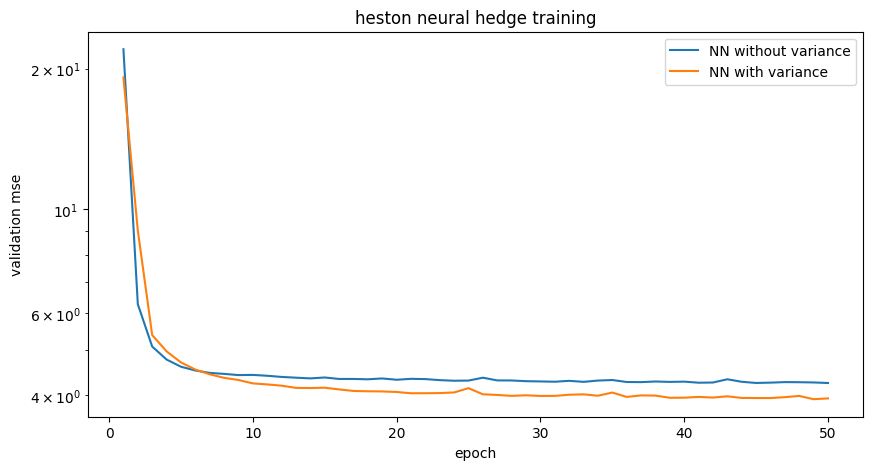

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    history_no_var["epoch"],
    history_no_var["val_loss"],
    label="NN without variance",
)

plt.plot(
    history_with_var["epoch"],
    history_with_var["val_loss"],
    label="NN with variance",
)

plt.yscale("log")

plt.xlabel("epoch")
plt.ylabel("validation mse")
plt.title("heston neural hedge training")

plt.legend()
plt.show()

In [15]:
def collect_neural_pnl(
    model,
    loader,
    use_variance
):
    def run_batch(model, batch):
        spot_paths, variance_paths = batch
        spot_paths = spot_paths.to(device=device, dtype=DTYPE)
        variance_paths = variance_paths.to(device=device, dtype=DTYPE)

        if use_variance:
            policy_variance = variance_paths
        else:
            policy_variance = torch.full_like(variance_paths, theta)

        return run_hedge_torch(
            model=model,
            spot_paths=spot_paths,
            variance_paths=policy_variance,
            K=K,
            T=T,
            premium=heston_premium,
            r=r,
            transaction_cost_rate=transaction_cost_rate,
        )["pnl"]

    return collect_pnl(model, loader, run_batch)

In [ ]:
_, _, test_loader = make_loaders(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        test_dataset=test_dataset,
        batch_size=batch_size,
        seed=SEED,
    )

nn_no_var_pnl = collect_neural_pnl(
    model=model_no_var,
    loader=test_loader,
    use_variance=False,
)

nn_with_var_pnl = collect_neural_pnl(
    model=model_with_var,
    loader=test_loader,
    use_variance=True,
)

In [17]:
bs_result = run_delta_hedge(
    stock_paths=test_sim_np.spot,
    K=K,
    sigma=sigma_bs,
    T=T,
    r=r,
    transaction_cost_rate=0.0,
    record_history=False,
    initial_premium=heston_premium,
)

bs_pnl = bs_result["pnl"]

In [18]:
comparison = pd.DataFrame({
    "BS fixed-vol delta": pnl_metrics(bs_pnl),
    "NN without variance": pnl_metrics(nn_no_var_pnl),
    "NN with variance": pnl_metrics(nn_with_var_pnl),
}).T

comparison

,mean_pnl,std_pnl,rmse,q05,q01,cvar95_loss,cvar99_loss
BS fixed-vol delta,0.008785,2.160468,2.160465,-3.672438,-6.330398,5.378384,8.217250
NN without variance,0.012270,2.064442,2.064458,-3.557803,-6.140122,5.207462,7.950748
NN with variance,0.015035,1.988341,1.988378,-3.565088,-5.651939,4.855959,6.875341


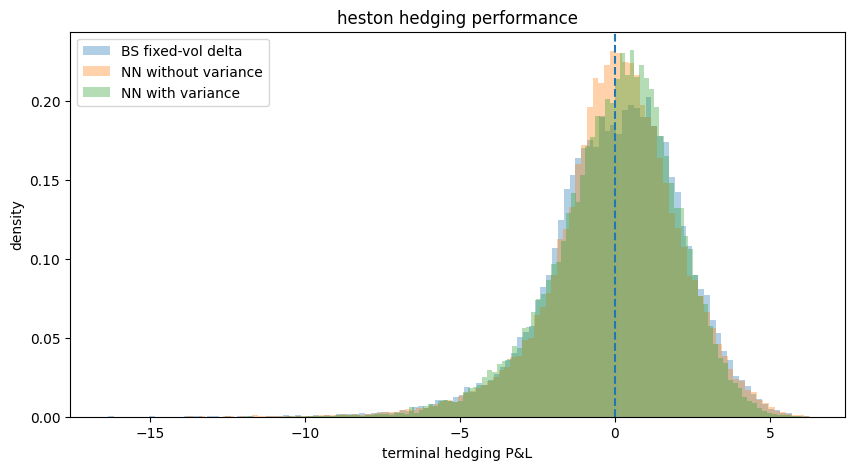

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(
    bs_pnl,
    bins=120,
    density=True,
    alpha=0.35,
    label="BS fixed-vol delta",
)

plt.hist(
    nn_no_var_pnl,
    bins=120,
    density=True,
    alpha=0.35,
    label="NN without variance",
)

plt.hist(
    nn_with_var_pnl,
    bins=120,
    density=True,
    alpha=0.35,
    label="NN with variance",
)

plt.axvline(0.0, linestyle="--")

plt.xlabel("terminal hedging P&L")
plt.ylabel("density")
plt.title("heston hedging performance")

plt.legend()
plt.show()

In [20]:
log_returns = np.diff(np.log(test_sim_np.spot), axis=1)
realized_variance = np.sum(log_returns**2, axis=1)
realized_volatility = np.sqrt(realized_variance)

rng = np.random.default_rng(123)
idx = rng.choice(n_test, size=10_000, replace=False)

vol_bucket = pd.qcut(
    realized_volatility,
    q=5,
    labels=[
        "lowest",
        "low",
        "medium",
        "high",
        "highest",
    ]
)

bucket_df = pd.DataFrame({
    "vol_bucket": vol_bucket,
    "bs_pnl": bs_pnl,
    "nn_no_var_pnl": nn_no_var_pnl,
    "nn_with_var_pnl": nn_with_var_pnl,
})

bucket_results = []

for bucket, group in bucket_df.groupby("vol_bucket", observed=False):
    bucket_results.append({
        "vol_bucket": bucket,
        "BS": np.sqrt(np.mean(group["bs_pnl"]**2)),
        "NN no var": np.sqrt(np.mean(group["nn_no_var_pnl"]**2)),
        "NN with var": np.sqrt(np.mean(group["nn_with_var_pnl"]**2)),
    })

bucket_results = pd.DataFrame(bucket_results)
bucket_results

,vol_bucket,BS,NN no var,NN with var
0,lowest,2.523975,2.291018,2.163639
1,low,1.637626,1.665262,1.575972
2,medium,0.976933,1.290459,1.328477
3,high,1.516924,1.640811,1.639726
4,highest,3.321191,2.988399,2.854760


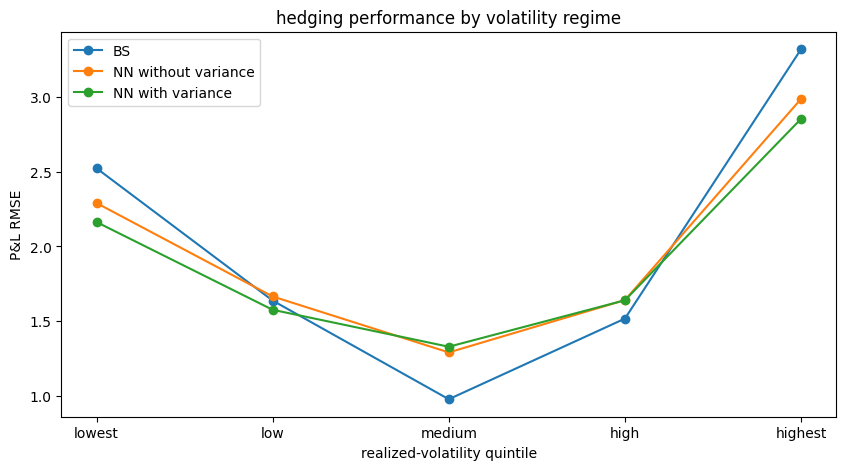

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    bucket_results["vol_bucket"],
    bucket_results["BS"],
    marker="o",
    label="BS",
)

plt.plot(
    bucket_results["vol_bucket"],
    bucket_results["NN no var"],
    marker="o",
    label="NN without variance",
)

plt.plot(
    bucket_results["vol_bucket"],
    bucket_results["NN with var"],
    marker="o",
    label="NN with variance",
)

plt.xlabel("realized-volatility quintile")
plt.ylabel("P&L RMSE")
plt.title("hedging performance by volatility regime")

plt.legend()
plt.show()

In [22]:
variance_grid = torch.linspace(0.05**2, 0.60**2, 300, device=device)

S_eval = 100.0
t_eval = 0.5
previous_position = 0.5

In [23]:
def policy_vs_variance(model, use_variance):
    with torch.no_grad():
        # a variance-blind policy always sees the long-run level
        v = variance_grid if use_variance else theta

        state = build_state(
            S=torch.full_like(variance_grid, S_eval),
            v=v,
            t=t_eval,
            shares=previous_position,
            K=K,
            T=T,
            variance_scale=theta,
        )

        target = model(state)

    return target.cpu().numpy()

In [24]:
vol_grid = torch.sqrt(variance_grid).cpu().numpy()

no_var_target = policy_vs_variance(model_no_var, use_variance=False)
with_var_target = policy_vs_variance(model_with_var, use_variance=True)

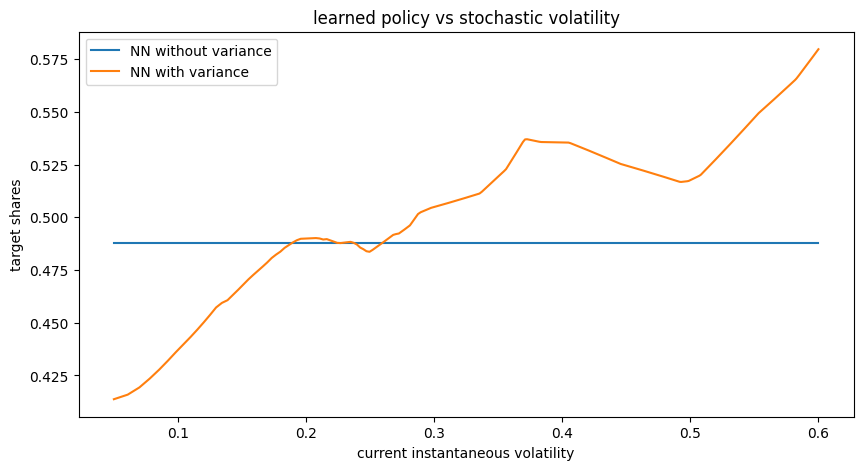

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    vol_grid,
    no_var_target,
    label="NN without variance",
)

plt.plot(
    vol_grid,
    with_var_target,
    label="NN with variance",
)

plt.xlabel("current instantaneous volatility")
plt.ylabel("target shares")
plt.title("learned policy vs stochastic volatility")

plt.legend()
plt.show()

In [26]:
vol_levels = [0.10, 0.20, 0.40]

S_grid = torch.linspace(60, 140, 300, device=device)

def policy_vs_spot(
    model,
    volatility,
    use_variance=True
):
    with torch.no_grad():
        v = volatility**2 if use_variance else theta

        state = build_state(
            S=S_grid,
            v=v,
            t=t_eval,
            shares=0.5,
            K=K,
            T=T,
            variance_scale=theta,
        )

        target = model(state)

    return target.cpu().numpy()

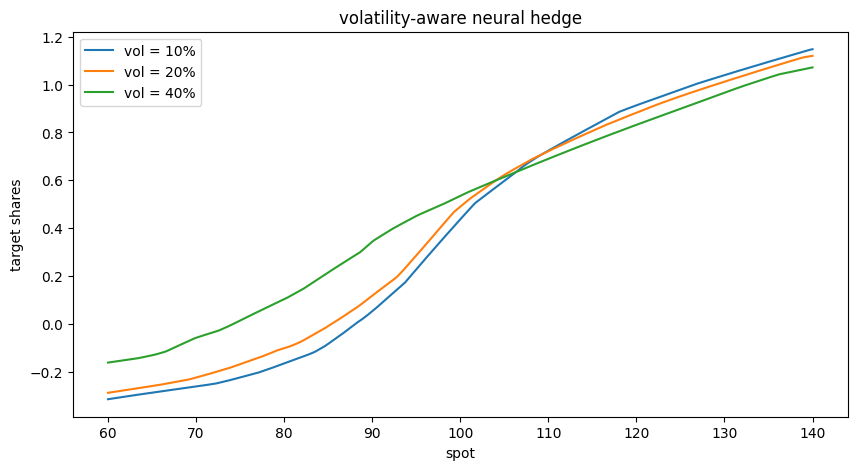

In [27]:
S_grid_np = S_grid.cpu().numpy()

plt.figure(figsize=(10, 5))

for vol in vol_levels:
    hedge = policy_vs_spot(
        model_with_var,
        volatility=vol,
        use_variance=True,
    )

    plt.plot(
        S_grid_np,
        hedge,
        label=f"vol = {vol:.0%}",
    )

plt.xlabel("spot")
plt.ylabel("target shares")
plt.title("volatility-aware neural hedge")

plt.legend()
plt.show()